#0. Funciones y código auxiliar

##0.1. Instalar las bibliotecas necesarias

In [1]:
!pip install ultralytics
!pip install roboflow
!pip install ultralytics -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 116.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
import os
import glob
import yaml
import shutil
from ultralytics import YOLO
from google.colab import drive
from roboflow import Roboflow


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 0.2 Funcion para distribuir los Datos

Funcion hecha para distribuir en porcentaje de los datos en las carpetas `train` , `valid` y  `test`.

In [3]:

import shutil
def redistribuir_dataset(input_dir, output_dir, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    print(f"\n INICIANDO REDISTRIBUCIÓN desde: {input_dir}")

    # Extensiones de imagen a buscar
    valid_extensions = ['.jpg', '.jpeg', '.png', '.bmp']
    all_pairs = []

    splits = ['train', 'valid', 'test']

    for split in splits:
        # Rutas esperadas según tu descripción
        img_dir = os.path.join(input_dir, split, 'images')
        lbl_dir = os.path.join(input_dir, split, 'labels')

        if not os.path.exists(img_dir):
            continue

        # Listamos todas las imágenes de esta carpeta
        files = os.listdir(img_dir)
        count_split = 0

        for f in files:
            name, ext = os.path.splitext(f)
            if ext.lower() in valid_extensions:
                img_path = os.path.join(img_dir, f)
                lbl_path = os.path.join(lbl_dir, name + ".txt")

                # Solo añadimos si existe su etiqueta correspondiente
                if os.path.exists(lbl_path):
                    all_pairs.append((img_path, lbl_path))
                    count_split += 1

        print(f"   Recolectadas {count_split} parejas de '{split}'")

    total_files = len(all_pairs)
    print(f" TOTAL DE PARES ENCONTRADOS: {total_files}")

    if total_files == 0:
        print(" ERROR: No se encontraron pares imagen/etiqueta. Verifica las rutas.")
        return None

    # 2. Barajamos aleatoriamente (Shuffle)
    random.shuffle(all_pairs)

    # 3. Calculamos los puntos de corte
    i_train = int(total_files * train_ratio)
    i_val = i_train + int(total_files * val_ratio)

    # Dividimos la lista
    datasets = {
        'train': all_pairs[:i_train],
        'valid': all_pairs[i_train:i_val],
        'test': all_pairs[i_val:]
    }

    # 4. Copiamos a la nueva carpeta de destino
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir) # Borramos si ya existe para empezar limpio

    print(f"\nCOPIANDO ARCHIVOS A: {output_dir} ...")

    for split, pairs in datasets.items():
        # Crear carpetas destino (ej: output/train/images)
        os.makedirs(os.path.join(output_dir, split, 'images'), exist_ok=True)
        os.makedirs(os.path.join(output_dir, split, 'labels'), exist_ok=True)

        for img_src, lbl_src in pairs:
            # Copiar Imagen
            shutil.copy(img_src, os.path.join(output_dir, split, 'images', os.path.basename(img_src)))
            # Copiar Label
            shutil.copy(lbl_src, os.path.join(output_dir, split, 'labels', os.path.basename(lbl_src)))

        print(f"   {split.upper()}: {len(pairs)} imágenes generadas.")

    # 5. Generar el nuevo archivo data.yaml
    # Intentamos leer los nombres de las clases del yaml original
    nombres_clases = []
    yaml_orig = os.path.join(input_dir, 'data.yaml')
    if os.path.exists(yaml_orig):
        try:
            with open(yaml_orig, 'r') as f:
                d = yaml.safe_load(f)
                nombres_clases = d.get('names', [])
        except: pass

    new_yaml = {
        'path': os.path.abspath(output_dir),
        'train': 'train/images',
        'val': 'valid/images',
        'test': 'test/images',
        'names': nombres_clases,
        'nc': len(nombres_clases)
    }

    with open(os.path.join(output_dir, 'data.yaml'), 'w') as f:
        yaml.dump(new_yaml, f)

    print(f"\n PROCESO COMPLETADO. nuevo dataset está en: {output_dir}")
    return output_dir

## 0.3 Función para analizar el Dataset

In [4]:
import os
import glob
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
import numpy as np
from collections import Counter

def analizar_yolo_dataset(dataset_dir):


    # CARGAR CONFIGURACIÓN (CLASES)

    yaml_path = os.path.join(dataset_dir, "data.yaml")
    class_names = []

    if os.path.exists(yaml_path):
        with open(yaml_path, 'r') as f:
            data = yaml.safe_load(f)
            names = data.get('names', [])
            # Normalizar si viene como diccionario o lista
            if isinstance(names, dict):
                class_names = [names[i] for i in sorted(names.keys())]
            else:
                class_names = names
        print(f" Clases detectadas: {class_names}")
    else:
        print("ADVERTENCIA: No se encontró 'data.yaml'. Se usarán IDs numéricos.")


    #  ESTADÍSTICAS Y GRÁFICAS

    print("\n Generando estadísticas...")

    # Busca etiquetas recursivamente
    label_files = glob.glob(f'{dataset_dir}/**/labels/*.txt', recursive=True)
    class_counts = Counter()

    for lfile in label_files:
        with open(lfile, 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    try:
                        cls_id = int(parts[0])
                        # Si tenemos nombres, usamos el nombre, si no, el ID
                        if class_names and 0 <= cls_id < len(class_names):
                            label = class_names[cls_id]
                        else:
                            label = str(cls_id)
                        class_counts[label] += 1
                    except ValueError: pass

    if class_counts:
        # Tabla
        print(f"\n{'CLASE':<30} | {'CANTIDAD':<10}")
        print("-" * 45)
        sorted_items = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
        for cls, count in sorted_items:
            print(f"{cls:<30} | {count:<10}")

        # Gráfico
        keys = [k for k, v in sorted_items]
        vals = [v for k, v in sorted_items]

        plt.figure(figsize=(12, 6))
        sns.barplot(x=keys, y=vals, hue=keys, legend=False, palette="viridis")
        plt.title(f"Distribución de Etiquetas (Total: {sum(vals)})")
        plt.xlabel("Clase")
        plt.ylabel("Frecuencia")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    else:
        print(" No se encontraron etiquetas válidas para graficar.")

    #  VISUALIZACIÓN DE IMÁGENES

    print("\n Generando ejemplos visuales...")

    all_images = glob.glob(f'{dataset_dir}/**/images/*.jpg', recursive=True) + \
                 glob.glob(f'{dataset_dir}/**/images/*.png', recursive=True) + \
                 glob.glob(f'{dataset_dir}/**/images/*.jpeg', recursive=True)

    if all_images:
        # Tomar hasta 6 muestras aleatorias
        samples = random.sample(all_images, min(len(all_images), 6))
        plt.figure(figsize=(15, 10))

        for i, img_path in enumerate(samples):
            img = cv2.imread(img_path)
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w, _ = img.shape

            # Buscar Label (Intenta ruta standard y fallback)
            label_path = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + ".txt"
            if not os.path.exists(label_path):
                 # Intento alternativo para estructuras anidadas
                 label_path = os.path.join(os.path.dirname(os.path.dirname(img_path)), 'labels', os.path.basename(img_path).rsplit('.', 1)[0] + ".txt")

            box_drawn = False
            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            try:
                                cls_id = int(parts[0])
                                cx, cy, bw, bh = map(float, parts[1:5])

                                x1 = int((cx - bw/2) * w)
                                y1 = int((cy - bh/2) * h)
                                x2 = int((cx + bw/2) * w)
                                y2 = int((cy + bh/2) * h)

                                color = plt.cm.tab10(cls_id % 10)
                                color_rgb = (int(color[0]*255), int(color[1]*255), int(color[2]*255))

                                cv2.rectangle(img, (x1, y1), (x2, y2), color_rgb, 3)

                                # Texto
                                if class_names and cls_id < len(class_names):
                                    label_txt = class_names[cls_id]
                                else:
                                    label_txt = str(cls_id)

                                text_y = y1 - 10 if y1 > 25 else y1 + 25
                                cv2.putText(img, label_txt, (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 4)
                                cv2.putText(img, label_txt, (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
                                box_drawn = True
                            except ValueError: pass

            plt.subplot(2, 3, i+1)
            plt.imshow(img)
            plt.axis('off')

            # Nombre de la carpeta padre (train/valid/test)
            parent_folder = os.path.basename(os.path.dirname(os.path.dirname(img_path)))

            if box_drawn:
                plt.title(f"[{parent_folder}] Detectado", fontsize=10)
            else:
                plt.title(f"[{parent_folder}] Sana/Fondo", color='green', fontsize=10)

        plt.tight_layout()
        plt.show()

    else:
        print(" No se encontraron imágenes en la ruta proporcionada.")

## 0.4 Analizar Estructura Dataset

Analiza la estructura del dataset , será importante posteriormente para verificar si se ha decargado bien y ver la distribución.

In [5]:

def analizar_estructura(dataset_dir):
    """
    Recorre las carpetas train, valid y test para contar imágenes.
    """
    if not dataset_dir or not os.path.exists(dataset_dir):
        print("El directorio del dataset no es válido.")
        return

    print(f"\nREPORTE DEL DATASET (Carpeta: {dataset_dir})")
    print("-" * 50)

    carpetas = ['train', 'valid', 'test']
    total_imgs = 0

    for carpeta in carpetas:
        ruta_split = os.path.join(dataset_dir, carpeta)
        ruta_imgs = os.path.join(ruta_split, 'images')

        # Verificar si 'images' está dentro o si es la raíz
        if not os.path.exists(ruta_imgs):
            ruta_imgs = ruta_split

        if os.path.exists(ruta_imgs) and os.path.isdir(ruta_imgs):
            # Se ha corregido el error tipográfico 'rutpatataa_imgs' aquí:
            imgs = glob.glob(os.path.join(ruta_imgs, '*.jpg')) + \
                   glob.glob(os.path.join(ruta_imgs, '*.jpeg')) + \
                   glob.glob(os.path.join(ruta_imgs, '*.png'))

            n = len(imgs)
            total_imgs += n
            print(f"{carpeta.upper()}: {n} imágenes encontradas.")
        else:
            if carpeta != 'test':
                print(f"{carpeta.upper()}: No encontrada.")

    print("-" * 50)
    print(f"TOTAL: {total_imgs} imágenes.")





## 0.5 Configurar Yaml

Edita el archivo data.yaml para usar rutas absolutas y relativas correctas.

In [6]:
def configurar_yaml(dataset_dir):
    if not dataset_dir: return

    yaml_path = os.path.join(dataset_dir, "data.yaml")

    if os.path.exists(yaml_path):
        try:
            with open(yaml_path, 'r') as f:
                data = yaml.safe_load(f)

            # Ajuste de rutas
            data['path'] = os.path.abspath(dataset_dir)
            data['train'] = "train/images"
            data['val'] = "valid/images"
            data['test'] = "test/images"

            with open(yaml_path, 'w') as f:
                yaml.dump(data, f, default_flow_style=False)

            print(f"\nArchivo corregido: {yaml_path}")
            if 'names' in data:
                print(f"Clases: {data['names']}")

        except Exception as e:
            print(f"Error editando yaml: {e}")
    else:
        print("No se encontró 'data.yaml'.")




Este notebook experimental se estructura en tres fases secuenciales para garantizar la selección del modelo óptimo.
- En la primera fase (Optimización de Datos), se analizará cada dataset individualmente para determinar la distribución de muestras  y las técnicas de Data Augmentation más eficaces para cada tipo de cultivo.
-  En la segunda fase (Torneo de Modelos), se ejecutará una comparativa técnica entre las distintas generaciones de la arquitectura YOLO (v3, v5, v8 y v11) para identificar qué versión se adapta mejor a las características específicas de cada conjunto de datos.
- Finalmente, en la tercera fase  se consolidarán los resultados métricos y los tiempos de inferencia de todos los escenarios para elegir una única arquitectura ganadora que ofrezca el mejor equilibrio entre precisión y eficiencia operativa.

#2 DATASET Prueba

In [7]:

rf = Roboflow(api_key="RApFtl6W6NZRZvedDpz2")
project = rf.workspace("germanrv-uyz9j").project("synthetic-drone-d2ius")
version = project.version(3)
dataset = version.download("yolov8")



loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to synthetic-drone-3 in yolov8:: 100%|██████████| 5822/5822 [00:01<00:00, 2974.42it/s]


In [8]:
dataset_dir = dataset.location
print(f"\n Descarga completada en: {dataset_dir}")


 Descarga completada en: /content/synthetic-drone-3


In [9]:
if dataset_dir:
   configurar_yaml(dataset_dir)


Archivo corregido: /content/synthetic-drone-3/data.yaml
Clases: ['dron']


In [10]:
dataset_dir_final = redistribuir_dataset(dataset_dir, "/content/dataset_repartido")


 INICIANDO REDISTRIBUCIÓN desde: /content/synthetic-drone-3
   Recolectadas 2591 parejas de 'train'
   Recolectadas 172 parejas de 'valid'
   Recolectadas 142 parejas de 'test'
 TOTAL DE PARES ENCONTRADOS: 2905

COPIANDO ARCHIVOS A: /content/dataset_repartido ...
   TRAIN: 2033 imágenes generadas.
   VALID: 435 imágenes generadas.
   TEST: 437 imágenes generadas.

 PROCESO COMPLETADO. nuevo dataset está en: /content/dataset_repartido


 Clases detectadas: ['dron']

 Generando estadísticas...

CLASE                          | CANTIDAD  
---------------------------------------------
dron                           | 2905      


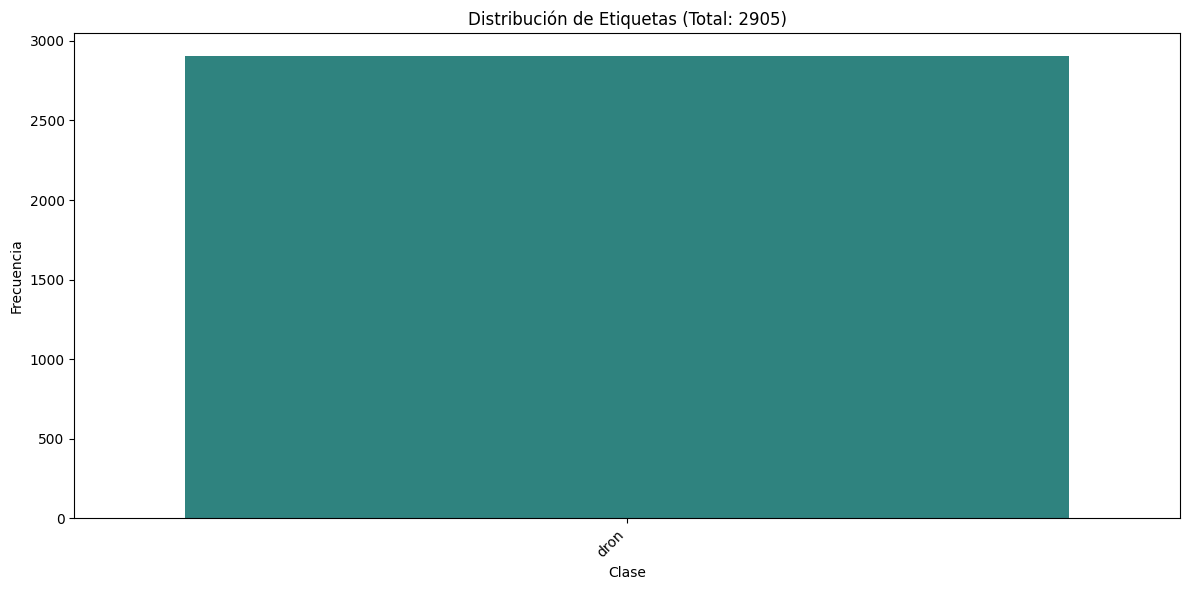


 Generando ejemplos visuales...


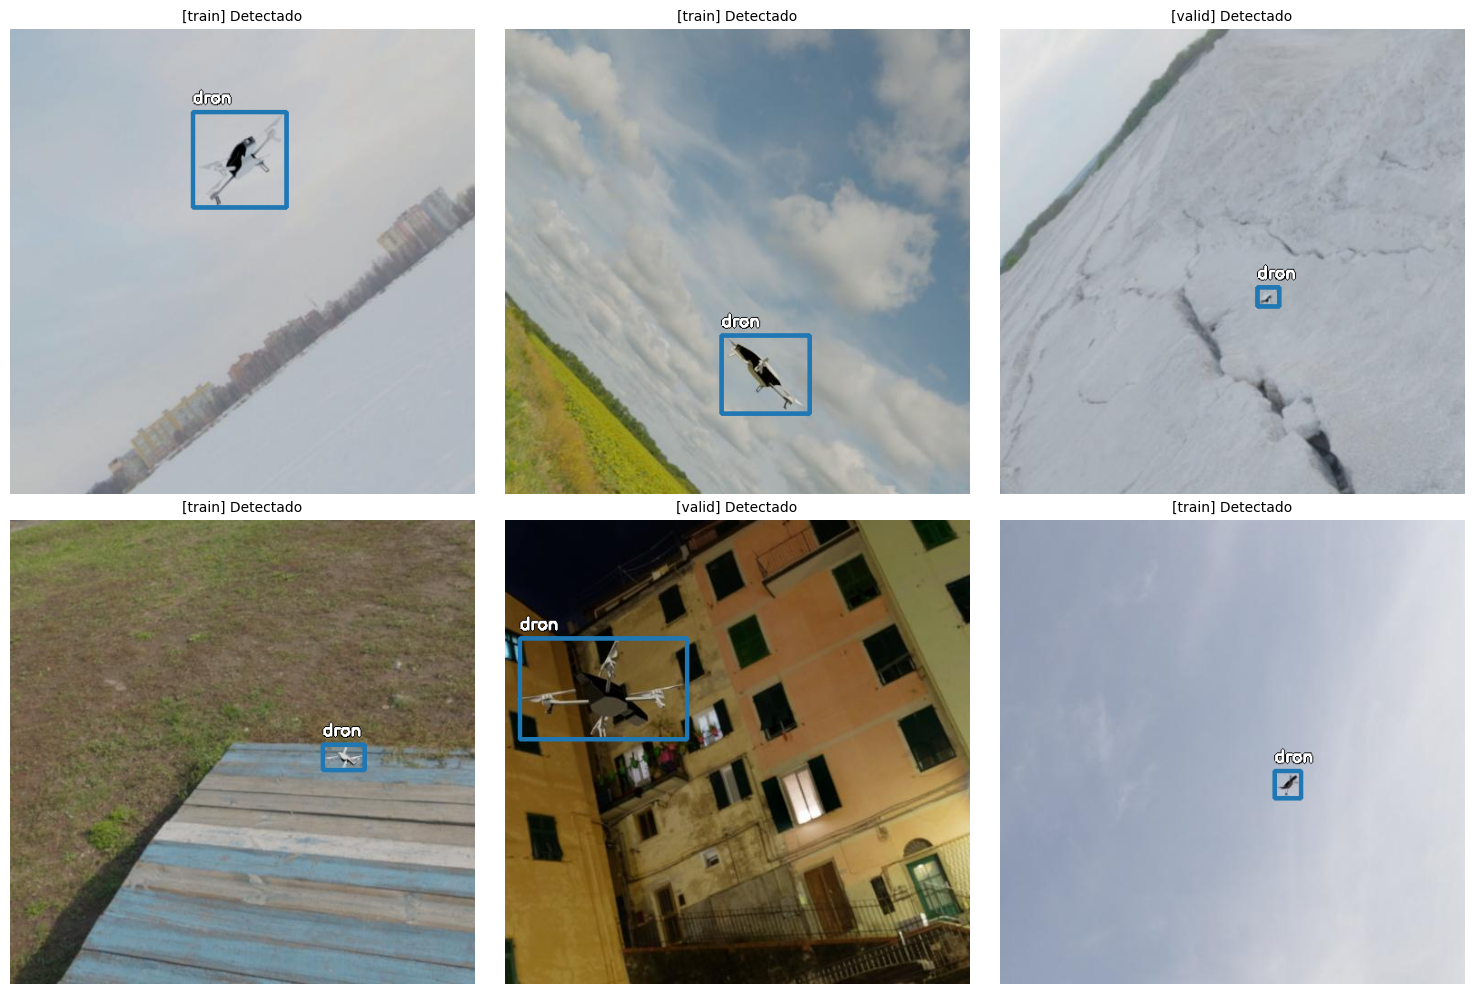

In [11]:
analizar_yolo_dataset(dataset_dir_final)

In [12]:
analizar_estructura(dataset_dir_final)


REPORTE DEL DATASET (Carpeta: /content/dataset_repartido)
--------------------------------------------------
TRAIN: 2033 imágenes encontradas.
VALID: 435 imágenes encontradas.
TEST: 437 imágenes encontradas.
--------------------------------------------------
TOTAL: 2905 imágenes.


Usando dataset en: /content/dataset_repartido

🚀 INICIANDO ENTRENAMIENTO CON: YOLOV8N

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_repartido/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=entrenamiento_yolov8

Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.


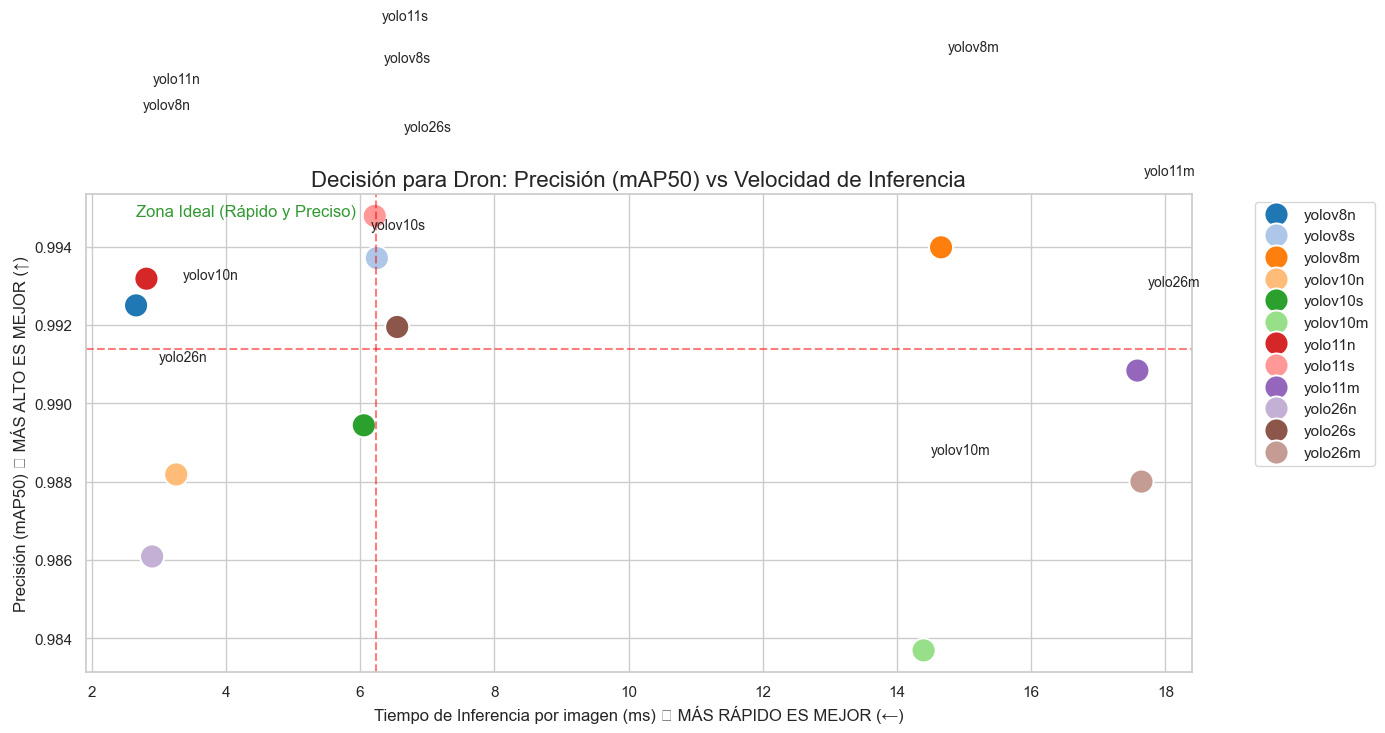



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



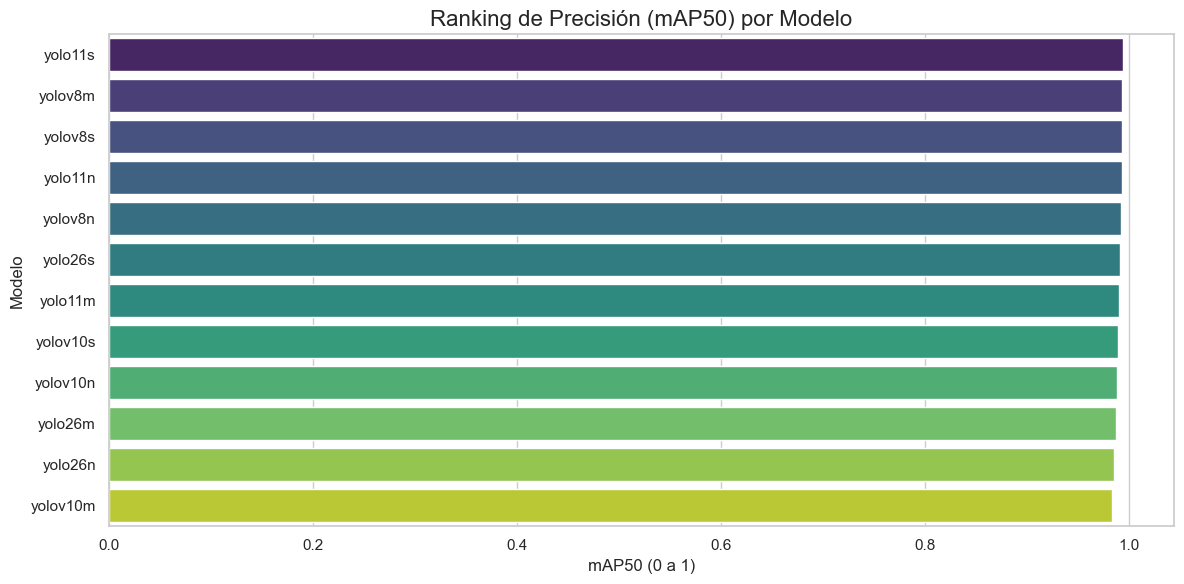

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

# ====================================================================
# FASE 2: MEGA TORNEO DE MODELOS (YOLOv8, YOLOv10, YOLO11 y YOLO26)
# Tamaños: Nano (n), Small (s), Medium (m)
# ====================================================================

if 'dataset_dir_final' not in globals() or not os.path.exists(dataset_dir_final):
    print("Error: La variable 'dataset_dir_final' no está definida o no existe.")
else:
    print(f"Usando dataset en: {dataset_dir_final}")
    ruta_yaml = os.path.join(dataset_dir_final, "data.yaml")

    # Lista ampliada de modelos a evaluar.
    modelos_a_entrenar = [
        'yolov8n.pt', 'yolov8s.pt', 'yolov8m.pt',
        'yolov10n.pt', 'yolov10s.pt', 'yolov10m.pt',
        'yolo11n.pt', 'yolo11s.pt', 'yolo11m.pt',
        'yolo26n.pt', 'yolo26s.pt', 'yolo26m.pt' # <-- ¡YOLO26 añadido al torneo!
    ]

    PROYECTO = 'runs/detect'
    resultados_metricas = []

    # Bucle de entrenamiento para cada modelo
    for nombre_pesos in modelos_a_entrenar:
        nombre_modelo = nombre_pesos.split('.')[0]

        print(f"\n{'='*60}")
        print(f"🚀 INICIANDO ENTRENAMIENTO CON: {nombre_modelo.upper()}")
        print(f"{'='*60}\n")

        try:
            # 1. Cargar el modelo
            model = YOLO(nombre_pesos)

            # 2. Entrenar el modelo
            # (Recuerda subir 'epochs' a 50 o 100 para el entrenamiento final del TFG)
            model.train(
                data=ruta_yaml,
                epochs=25,
                imgsz=512,
                batch=16,
                project=PROYECTO,
                name=f"entrenamiento_{nombre_modelo}",
                plots=False
            )

            # 3. Validar para extraer métricas limpias
            print(f"\n📊 Extrayendo métricas de {nombre_modelo}...")
            metrics = model.val()

            # 4. Guardar los resultados clave
            tiempo_inferencia = metrics.speed['inference']
            map50 = metrics.box.map50
            map50_95 = metrics.box.map

            resultados_metricas.append({
                'Modelo': nombre_modelo,
                'mAP50': map50,
                'mAP50-95': map50_95,
                'Inferencia_ms': tiempo_inferencia
            })

        except Exception as e:
            print(f"❌ Error al evaluar {nombre_modelo}: {e}")
            print("Saltando al siguiente modelo...")

    print("\n✅ ENTRENAMIENTO DE TODOS LOS MODELOS FINALIZADO.")

    # ====================================================================
    # FASE 3: GRÁFICAS DE DECISIÓN PARA EL DRON (INCLUIR EN EL TFG)
    # ====================================================================

    if len(resultados_metricas) > 0:
        # Convertir resultados a un DataFrame de Pandas
        df_metricas = pd.DataFrame(resultados_metricas)
        print("\n📊 TABLA DE RESULTADOS:")
        print(df_metricas.to_string(index=False))

        sns.set_theme(style="whitegrid")

        # ---------------------------------------------------------
        # Gráfica 1: Trade-off (Inferencia vs mAP50)
        # ---------------------------------------------------------
        plt.figure(figsize=(14, 8))
        ax = sns.scatterplot(data=df_metricas, x='Inferencia_ms', y='mAP50', hue='Modelo', s=300, palette="tab20")

        plt.title('Decisión para Dron: Precisión (mAP50) vs Velocidad de Inferencia', fontsize=16, fontweight='bold')
        plt.xlabel('Tiempo de Inferencia por imagen (ms) ➔ MÁS RÁPIDO ES MEJOR (←)', fontsize=12)
        plt.ylabel('Precisión (mAP50) ➔ MÁS ALTO ES MEJOR (↑)', fontsize=12)

        # Etiquetar cada punto con el nombre de su modelo
        for i in range(df_metricas.shape[0]):
            plt.text(df_metricas['Inferencia_ms'][i] + 0.1,
                     df_metricas['mAP50'][i] + 0.005,
                     df_metricas['Modelo'][i],
                     fontsize=10)

        # Dibujar líneas guía marcando las medianas
        plt.axvline(x=df_metricas['Inferencia_ms'].median(), color='red', linestyle='--', alpha=0.5)
        plt.axhline(y=df_metricas['mAP50'].median(), color='red', linestyle='--', alpha=0.5)

        # Marcar el cuadrante ganador
        plt.text(df_metricas['Inferencia_ms'].min(), df_metricas['mAP50'].max(),
                 'Zona Ideal (Rápido y Preciso)', color='green', fontsize=12, alpha=0.8, fontweight='bold')

        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

        # ---------------------------------------------------------
        # Gráfica 2: Barplot Comparativa de Precisión Pura
        # ---------------------------------------------------------
        plt.figure(figsize=(12, 6))
        df_sorted = df_metricas.sort_values('mAP50', ascending=False)
        sns.barplot(data=df_sorted, x='mAP50', y='Modelo', palette='viridis')
        plt.title('Ranking de Precisión (mAP50) por Modelo', fontsize=16, fontweight='bold')
        plt.xlabel('mAP50 (0 a 1)')
        plt.ylabel('Modelo')
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ No se pudieron recopilar métricas de ningún modelo.")

In [14]:


# ENTRENAMIENTO
if 'dataset_dir_final' not in globals():
    print("Error: La variable 'dataset_dir_final' no está definida.")

else:
    print(f"Usando dataset en: {dataset_dir_final}")

    ruta_yaml = os.path.join(dataset_dir_final, "data.yaml")

    if not os.path.exists(ruta_yaml):
        print(f"Error: No se encuentra el archivo {ruta_yaml}")
    else:
        print("Iniciando entrenamiento con YOLO11m...")

        # Definimos nombres para poder ubicar los archivos después
        PROYECTO = 'runs/detect'
        NOMBRE_EJECUCION = 'entrenamiento_drone'

        model = YOLO('yolov8n.pt')

        model.train(
            data=ruta_yaml,
            epochs=12,
            imgsz=512,
            batch=16,
            project=PROYECTO,
            name=NOMBRE_EJECUCION,
            plots=True
        )

        print("Entrenamiento finalizado.")




Usando dataset en: /content/dataset_repartido
Iniciando entrenamiento con YOLO11m...
Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_repartido/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=12, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=entrenamiento_drone, n


⬇ Sube una foto de tu dron (o del escenario) para probar


Saving frame_03571.jpg to frame_03571.jpg

Analizando imagen: frame_03571.jpg ...

image 1/1 /content/frame_03571.jpg: 416x512 1 dron, 47.2ms
Speed: 1.8ms preprocess, 47.2ms inference, 7.5ms postprocess per image at shape (1, 3, 416, 512)
Results saved to /content/runs/detect/predict


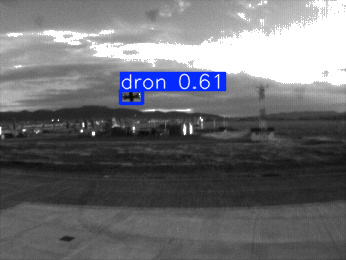

--> Detectado: dron (60.7%)


In [16]:
import os
from ultralytics import YOLO
from google.colab import files
from google.colab.patches import cv2_imshow


print("\n⬇ Sube una foto de tu dron (o del escenario) para probar")
uploaded = files.upload()


for filename in uploaded.keys():
    print(f"\nAnalizando imagen: {filename} ...")

    # conf=0.25 -> Bajamos un poco la confianza por si es la primera prueba
    results = model.predict(source=filename, conf=0.1, save=True)

    # Mostrar resultados
    for result in results:
        # Dibujar las cajas
        imagen_con_cajas = result.plot()

        # Mostrar en Colab
        cv2_imshow(imagen_con_cajas)

        # Imprimir qué detectó en texto
        if len(result.boxes) == 0:
            print(" No se detectó nada. Intenta bajar el 'conf' o usar una foto más clara.")
        else:
            for box in result.boxes:
                clase = result.names[int(box.cls[0])]
                confianza = float(box.conf[0])
                print(f"--> Detectado: {clase} ({confianza:.1%})")